# Lesson 23 K Nearest Neighbors for Classification

Goal is to classify the energy consumption patter in the corresponding device. We will be using the **consumption.csv** dataset. 

# Data

## EDA  

The data we have allows us to classify based on the labels that were already created. 

We can see there is a mild imbalance where most of the data is heavily skewed towards classes 4 1 and 3.   <mark> Nans report: </mark> there are no Nan values.  
<img src="k_nearest_neighbors.png" width="200">


## Train Test Split  

As a classification problem, we will be doing a typical spatial-based train-test split as opposed to time series with sliding windows.  

Remember to do **stratification** especially since we have classes and these classes are imbalanced. 

## Scaling Data
Knn works from the recovery of the nearest neighbors from their distance so it is important that all attributes are the same scale.... This is why it's <mark> important to scale </mark> them. 

We use the **min max scaler**.


# Training K Nearest Neighbors  

 We will be tuning the **hyperparameters** necessary in KNN for classification. These include:

 - `n_neighbors`: Number of neighbors to use.
 - `weights`: Weight function used in prediction. 
 - `leaf_size`: Leaf size passed to KDTree.
 - `metric`: Metric to use for distance computation. 

 The **cosine metric** measures the "distance" between two vectors by computing their dot product distance:  

 \begin{align}
    \cos(\theta)  = \frac{A \cdot B}{||A||_2 ||B||_2}
 \end{align}

We can see multiple of the first top values based on the mean_test_score are all 'l1'-scored, with 7 neighbors, a distance weight, and varying leaf size.  
<img src="knn_gridsearch_results.png" width="500">  

# Performance Evaluation  

## Classification Report  

This report shows we have a decent recall but our precision could be better. 

Remember **precision** is:

What proportion of positive identifications was actually correct? 
\begin{align}
    \textbf{precision} = \frac{TP}{TP + FP}
\end{align}  

Remmeber that **recall** is:

What proportion of actual positive values was identified correctly?
\begin{align}
    \textbf{recall} = \frac{TP}{TP + FN}
\end{align}  

In this case, we have a low precision and recall for category 5. Our F-1 scores are also not super great in this particular case.  

<img src="classification_report.png" width="350">  

## Confusion Matrix  
The confusion matrix shows a strong diagonal with the worst misclassifcations being for true category 3.    
<img src="confusion_matrix.png" width="400">


## Receiver Operating Characteristic Curve (ROC) / AUC  

The receiver operating characteristic curve ROC and AUC are showing okay results except for classes 5 and 6. Relating to the F1 score, we have that class 1 has the best performance. 

<img src="receiver_operating_characteristic_curve.png" width="500">


# Import

In [2]:
#%cd ..

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Library import data

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from skopt import BayesSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

from yellowbrick.classifier.rocauc import roc_auc

from IPython.display import display, HTML
show_html = lambda html: display(HTML(html))

# Get Data

In [9]:
df = data.get_data("Datasets/Consumption.csv", index_col=[0])
df

,Class,H00:00,H00:15,H00:30,H00:45,H01:00,H01:15,H01:30,H01:45,H02:00,...,H21:30,H21:45,H22:00,H22:15,H22:30,H22:45,H23:00,H23:15,H23:30,H23:45
0,0,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,...,5.99020,2.91270,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611,-0.18611
1,0,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700,...,0.19151,6.47670,1.64510,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700,-0.17700
2,0,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,...,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353,-0.21353
3,0,-0.17147,-0.17147,-0.17147,-0.17147,-0.17147,-0.17147,-0.17147,-0.17147,-0.17147,...,0.16088,0.18043,0.16088,7.35540,1.17750,-0.17147,-0.17147,-0.17147,-0.17147,-0.17147
4,0,-0.16927,-0.16927,-0.16927,-0.16927,-0.16927,-0.16927,-0.16927,-0.16927,-0.16927,...,0.19095,6.07440,0.17093,0.19095,0.19095,7.39520,0.85133,-0.16927,-0.16927,-0.16927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8921,4,-0.61198,-0.61198,-0.61198,-0.61198,-0.61198,-0.61198,-0.61198,-0.61198,-0.61198,...,1.79450,1.62850,1.71150,1.71150,1.71150,1.62850,-0.61198,-0.61198,-0.61198,-0.61198
8922,4,-0.49837,-0.49837,-0.49837,-0.49837,-0.49837,-0.49837,-0.49837,-0.49837,-0.49837,...,2.21890,2.31600,2.31600,2.21890,2.21890,1.73370,-0.49837,-0.49837,-0.49837,-0.49837
8923,4,-0.39939,-0.39939,-0.39939,-0.39939,-0.39939,-0.39939,-0.39939,-0.39939,-0.39939,...,2.64690,2.64690,2.64690,2.43680,2.64690,2.54190,0.44097,-0.39939,-0.39939,-0.39939
8924,4,-0.59560,-0.59560,-0.59560,-0.59560,-0.59560,-0.59560,-0.59560,-0.59560,-0.59560,...,1.95930,1.78310,1.78310,1.87120,1.78310,1.78310,1.78310,1.87120,1.87120,1.78310


# EDA

In [78]:
# Size / Shape
df.shape

# Value Counts
df["Class"].value_counts()

# Describe
df.describe().T

# Nans
df.isna().sum()
for c in df.columns:
    if df[c].isna().sum() > 0:
        print(c, data[c].isna().sum())

# Categories
categories = [str(c) for c in df["Class"].unique()]

# Train Test Split

In [40]:
from sklearn.model_selection import train_test_split

# Split raw data.
X = df.iloc[:, df.columns != "Class"]
y = df["Class"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)


# Scaling Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit and transform the features datasets.
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.fit_transform(X_test)

# Training K Nearest Neighbors for Classification

In [93]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import GridSearchCV

# Estimator
knn = KNeighborsClassifier()

# Params
params = {
    "n_neighbors": [1, 3, 5, 7, 11, 15],
    "weights": ["distance", "uniform"],
    "leaf_size": [1, 5, 10, 20, 30],
    "metric": ["l2", "l1", "cosine"]
}

# Grid Search / Bayes Search CV
knn_gscv = GridSearchCV(knn, params, cv=5, n_jobs=-1, refit=True)

# Fit and Transform
knn_gscv.fit(X_train_s, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'leaf_size': [1, 5, 10, 20, 30],
                         'metric': ['l2', 'l1', 'cosine'],
                         'n_neighbors': [1, 3, 5, 7, 11, 15],
                         'weights': ['distance', 'uniform']})

In [94]:
df_html = pd.DataFrame(knn_gscv.cv_results_)
df_html = df_html.loc[:, ["params", "mean_test_score", "rank_test_score"]]
show_html(df_html.sort_values(by="rank_test_score").head().to_html())

,params,mean_test_score,rank_test_score
54,"{'leaf_size': 5, 'metric': 'l1', 'n_neighbors': 7, 'weights': 'distance'}",0.734615,1
126,"{'leaf_size': 20, 'metric': 'l1', 'n_neighbors': 7, 'weights': 'distance'}",0.734615,1
18,"{'leaf_size': 1, 'metric': 'l1', 'n_neighbors': 7, 'weights': 'distance'}",0.734615,1
90,"{'leaf_size': 10, 'metric': 'l1', 'n_neighbors': 7, 'weights': 'distance'}",0.734615,1
162,"{'leaf_size': 30, 'metric': 'l1', 'n_neighbors': 7, 'weights': 'distance'}",0.734615,1


# Performance Metrics

# Classification Report

In [95]:
from sklearn.metrics import classification_report

y_pred = knn_gscv.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=categories))

              precision    recall  f1-score   support

           0       0.54      0.72      0.62       240
           1       0.94      0.93      0.94       736
           2       0.54      0.59      0.56       281
           3       0.57      0.68      0.62       487
           4       0.86      0.78      0.82       794
           5       0.29      0.32      0.30       168
           6       0.69      0.34      0.45       240

    accuracy                           0.71      2946
   macro avg       0.63      0.62      0.62      2946
weighted avg       0.73      0.71      0.72      2946



# Confusion Matrix

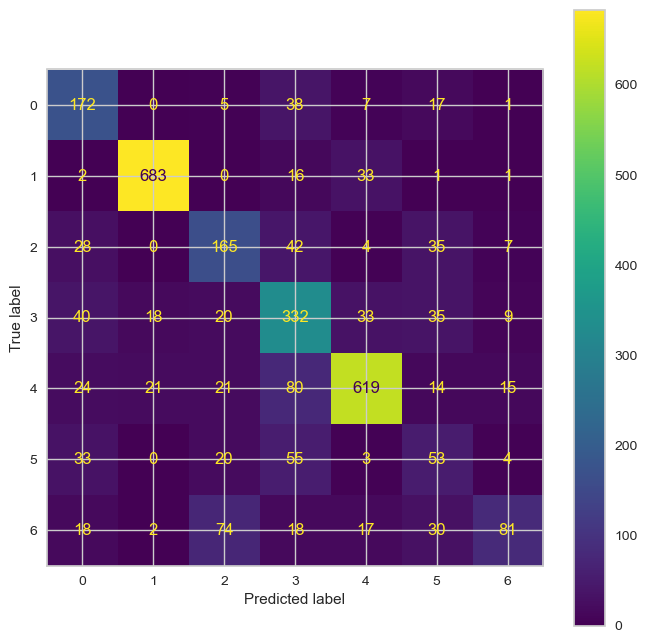

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(knn_gscv, X_test_s, y_test, display_labels=categories, ax=plt.subplot())

# Receiver Operating Characteristic (ROC) Curve

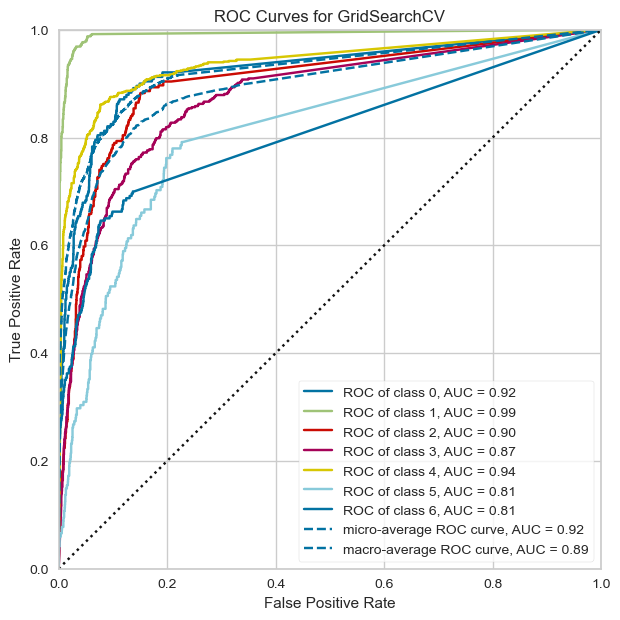

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for GridSearchCV'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       classes=['0', '1', '2', '3', '4', '5', '6'],
       estimator=GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
                              param_grid={'leaf_size': [1, 5, 10, 20, 30],
                                          'metric': ['l2', 'l1', 'cosine'],
                                          'n_neighbors': [1, 3, 5, 7, 11, 15],
                                          'weights': ['distance', 'uniform']}))

In [97]:
from yellowbrick.classifier.rocauc import roc_auc

plt.figure(figsize=(7, 7))

roc_auc(knn_gscv, X_train_s, y_train, X_test_s, y_test, ax=plt.subplot(), classes=categories)


